# Training Dynamics: Loss Functions, Optimizers, and Regularization

## The training landscape

Training a neural network means navigating a high-dimensional loss surface to find parameters that generalize well.

Three knobs control this process:

1. **Loss function** — *what* we minimize (defines the objective)
2. **Optimizer** — *how* we update weights (the step strategy)
3. **Regularization** — *constraints* that prevent memorizing noise

We will explore each one with runnable experiments on a small 2D dataset.

## Toy dataset: make_moons

We use `make_moons` from scikit-learn — a 2-class dataset that is **not** linearly separable but simple enough to visualize.

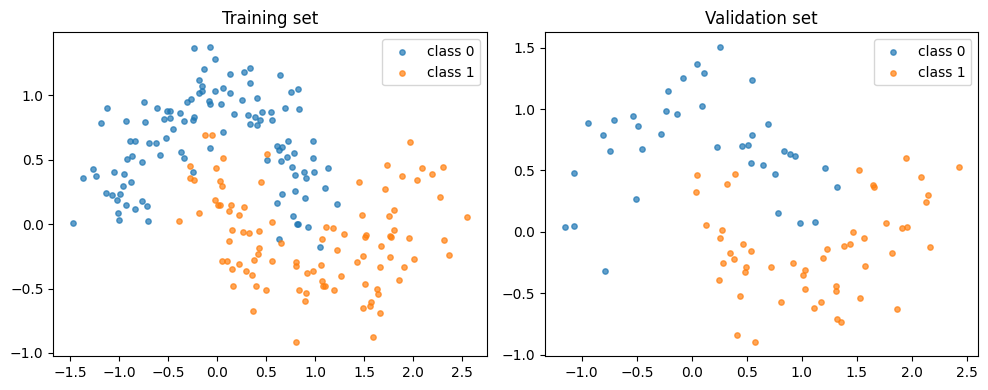

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

X, y = make_moons(n_samples=300, noise=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1)
X_val_t = torch.FloatTensor(X_val)
y_val_t = torch.FloatTensor(y_val).unsqueeze(1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (Xp, title) in zip(axes, [(X_train, "Training set"), (X_val, "Validation set")]):
    ax.scatter(Xp[y_train == 0 if "Train" in title else y_val == 0, 0],
               Xp[y_train == 0 if "Train" in title else y_val == 0, 1],
               s=15, alpha=0.7, label="class 0")
    ax.scatter(Xp[y_train == 1 if "Train" in title else y_val == 1, 0],
               Xp[y_train == 1 if "Train" in title else y_val == 1, 1],
               s=15, alpha=0.7, label="class 1")
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.show()

## Loss functions

The loss function quantifies **how wrong** the model's predictions are.

| Task | Loss | PyTorch | Notes |
|------|------|---------|-------|
| Regression | Mean Squared Error | `nn.MSELoss()` | Penalizes large errors quadratically |
| Binary classification | Binary Cross-Entropy | `nn.BCEWithLogitsLoss()` | Expects raw logits (more numerically stable than `nn.BCELoss` + sigmoid) |
| Multi-class classification | Cross-Entropy | `nn.CrossEntropyLoss()` | Expects raw logits, applies softmax internally |

**Rule of thumb:** for classification, always use the `WithLogits` / `CrossEntropy` variants and let PyTorch apply sigmoid/softmax internally — this avoids numerical issues with log(0).

### Quick demo: BCE loss on make_moons

We train the same small model with `BCEWithLogitsLoss` — the standard choice for binary problems.

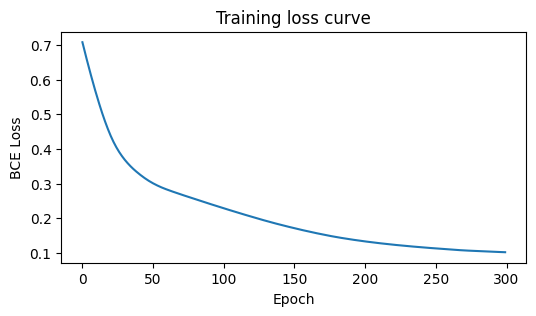

In [4]:
model = nn.Sequential(nn.Linear(2, 16), nn.ReLU(), nn.Linear(16, 1))
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

losses = []
for epoch in range(300):
    optimizer.zero_grad()
    loss = criterion(model(X_train_t), y_train_t)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

plt.figure(figsize=(6, 3))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.title("Training loss curve")
plt.show()

## Optimizers

All optimizers follow the same idea: **update weights in the direction that reduces the loss**. They differ in how they calculate the step.

| Optimizer | Intuition | When to use |
|-----------|-----------|-------------|
| `SGD` | "Walk downhill" — follows the raw gradient | Baseline, good for convex problems |
| `SGD + momentum` | "Ball rolling downhill" — accumulates velocity | Faster convergence, escapes shallow local minima |
| `RMSprop` | "Adaptive step size" — scales LR per parameter | Good for non-stationary objectives (e.g. RNNs) |
| **`Adam`** | Combines momentum + adaptive LR | **Default choice** for most deep learning problems |

**Practical recommendation:** start with `Adam(lr=1e-3)`. If you need to squeeze the last %, switch to `SGD + momentum` with a learning rate schedule.

> **Want to see optimizers in action?** Open ➜ [complementary/tf_playground_guide.ipynb](complementary/tf_playground_guide.ipynb) and experiment with different learning rates interactively.

### Comparison experiment

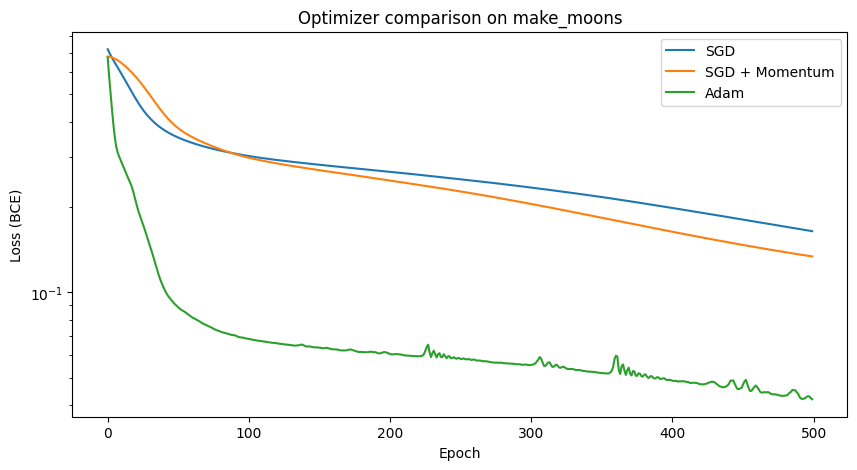

In [5]:
def train_with_optimizer(opt_fn, lr, epochs=500):
    model = nn.Sequential(nn.Linear(2, 64), nn.ReLU(), nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, 1))
    optimizer = opt_fn(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()
    losses = []
    for _ in range(epochs):
        optimizer.zero_grad()
        loss = criterion(model(X_train_t), y_train_t)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return losses

configs = [
    (lambda p, lr: optim.SGD(p, lr=lr), 0.1, "SGD"),
    (lambda p, lr: optim.SGD(p, lr=lr, momentum=0.9), 0.01, "SGD + Momentum"),
    (lambda p, lr: optim.Adam(p, lr=lr), 0.01, "Adam"),
]

plt.figure(figsize=(10, 5))
for opt_fn, lr, name in configs:
    losses = train_with_optimizer(opt_fn, lr)
    plt.plot(losses, label=name)
plt.xlabel("Epoch")
plt.ylabel("Loss (BCE)")
plt.yscale("log")
plt.title("Optimizer comparison on make_moons")
plt.legend()
plt.show()

**What to observe:**
- **SGD** converges slowly and may plateau early.
- **SGD + Momentum** accelerates past flat regions.
- **Adam** typically reaches a low loss fastest thanks to adaptive learning rates.

## Overfitting and regularization

**Overfitting** happens when the model memorizes the training data (including noise) instead of learning the underlying pattern.

**Tell-tale sign:** training loss keeps decreasing while validation loss starts **increasing**.

Three common defenses:

| Technique | How it works | PyTorch |
|-----------|-------------|---------|
| **Weight decay (L2)** | Penalizes large weights — shrinks them towards zero | `Adam(..., weight_decay=1e-4)` |
| **Dropout** | Randomly zeros neurons during training — forces redundancy | `nn.Dropout(p=0.5)` |
| **Early stopping** | Stop training when validation loss stops improving | Manual check in training loop |

### Experiment: baseline vs. regularized

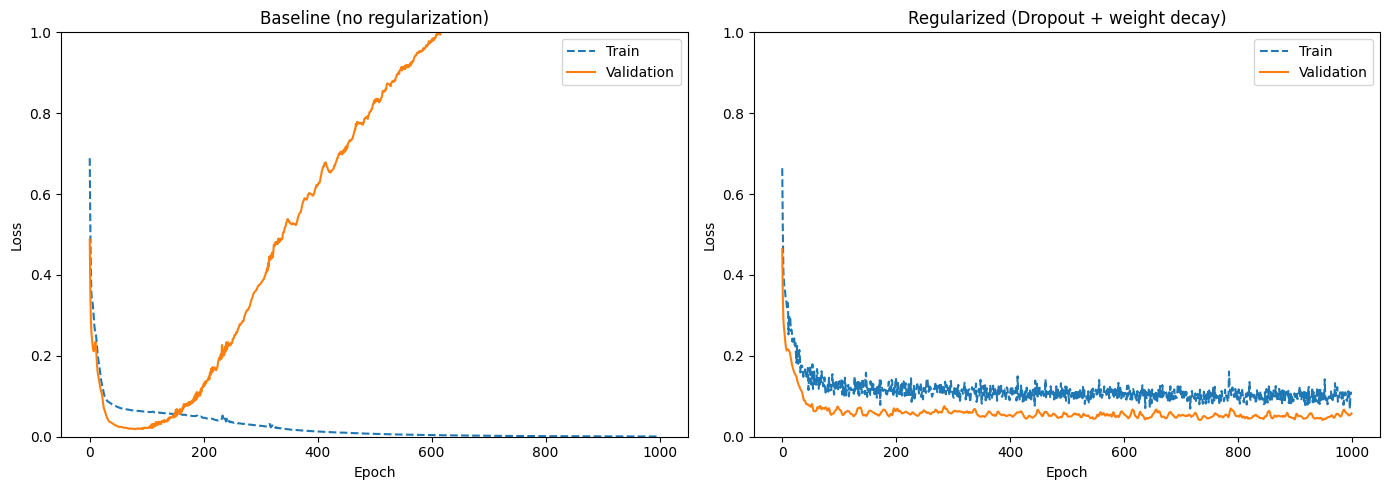

In [6]:
class FlexibleModel(nn.Module):
    def __init__(self, dropout: float = 0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, 128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        return self.net(x)

def train_and_record(model, weight_decay: float = 0.0, epochs: int = 1000):
    optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=weight_decay)
    criterion = nn.BCEWithLogitsLoss()
    train_losses, val_losses = [], []

    for _ in range(epochs):
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(X_train_t), y_train_t)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_t), y_val_t)
            val_losses.append(val_loss.item())
    return train_losses, val_losses

# Baseline (overparameterized, no regularization)
baseline = FlexibleModel(dropout=0.0)
bl_train, bl_val = train_and_record(baseline, weight_decay=0.0)

# Regularized (dropout + weight decay)
regularized = FlexibleModel(dropout=0.5)
reg_train, reg_val = train_and_record(regularized, weight_decay=1e-3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (tr, vl, title) in zip(axes, [
    (bl_train, bl_val, "Baseline (no regularization)"),
    (reg_train, reg_val, "Regularized (Dropout + weight decay)"),
]):
    ax.plot(tr, label="Train", linestyle="--")
    ax.plot(vl, label="Validation")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(title)
    ax.set_ylim(0, 1.0)
    ax.legend()
plt.tight_layout()
plt.show()

**What to observe:**
- **Baseline**: validation loss eventually rises even as training loss drops — classic overfitting.
- **Regularized**: the gap between train and validation is smaller, showing better generalization.

## Learning rate scheduling

The learning rate (LR) is the single most impactful hyperparameter:
- **Too high** → the loss oscillates or diverges.
- **Too low** → training is painfully slow.

**Schedulers** adjust the LR during training, typically starting high and decaying over time.

| Scheduler | Behavior | Use case |
|-----------|----------|----------|
| `StepLR` | Multiply LR by γ every N epochs | Simple, reliable |
| `CosineAnnealingLR` | Follows a cosine curve to near-zero | Smooth decay, popular in vision |
| `ReduceLROnPlateau` | Cuts LR when a metric stalls | Doesn't need predefined schedule |

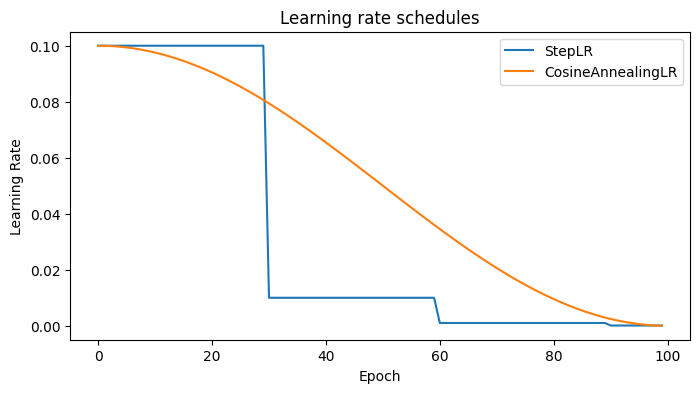

In [7]:
model = nn.Linear(10, 1)
optimizer = optim.SGD(model.parameters(), lr=0.1)

# Three schedulers for comparison
schedulers = {
    "StepLR (step=30, γ=0.1)": optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1),
}

# Reset and collect LR for StepLR
lrs_step = []
for epoch in range(100):
    optimizer.step()
    lrs_step.append(optimizer.param_groups[0]["lr"])
    schedulers["StepLR (step=30, γ=0.1)"].step()

# CosineAnnealing
optimizer2 = optim.SGD(model.parameters(), lr=0.1)
sched_cos = optim.lr_scheduler.CosineAnnealingLR(optimizer2, T_max=100)
lrs_cos = []
for epoch in range(100):
    optimizer2.step()
    lrs_cos.append(optimizer2.param_groups[0]["lr"])
    sched_cos.step()

plt.figure(figsize=(8, 4))
plt.plot(lrs_step, label="StepLR")
plt.plot(lrs_cos, label="CosineAnnealingLR")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Learning rate schedules")
plt.legend()
plt.show()

## Summary

| Component | Practical default |
|-----------|------------------|
| **Loss** | `CrossEntropyLoss` (multi-class) or `BCEWithLogitsLoss` (binary) |
| **Optimizer** | `Adam(lr=1e-3)` — switch to SGD + momentum for fine-tuning |
| **Regularization** | Dropout (0.2–0.5) in hidden layers + small weight_decay |
| **LR schedule** | `ReduceLROnPlateau` for robustness, `CosineAnnealing` for vision |
| **Monitoring** | Always compare train vs. validation loss to detect overfitting |